In [1]:
import tensorflow as tf
from keras.src.legacy.preprocessing.image import ImageDataGenerator

In [2]:
# 1. scale the pixel value from 0-255 to 0-1
# 2. Normalization -> model faster
# 3. shear_range = 0.2 --> 20%
# 4. zoom-range
# 5. horizonal flip

In [3]:
# 1. Data Preprocessing 
# processing on train data

In [4]:
train_datagen = ImageDataGenerator(rescale =1./255,
                                  shear_range =0.2,
                                  zoom_range =0.2,
                                  horizontal_flip = True)
training_set = train_datagen.flow_from_directory(r"D:\Internship_June2025\archive (1)\kagglecatsanddogs_5340\PetImages\train",
                                                target_size=(64,64),
                                                batch_size = 32,
                                                class_mode ='binary')                                                

Found 24998 images belonging to 2 classes.


In [5]:
test_datagen = ImageDataGenerator(rescale =1./255,
                                  shear_range =0.2,
                                  zoom_range =0.2,
                                  horizontal_flip = True)
test_set = test_datagen.flow_from_directory(r"D:\Internship_June2025\archive (1)\kagglecatsanddogs_5340\PetImages\test",
                                                target_size=(64,64),
                                                batch_size = 32,
                                                class_mode ='binary')                                                

Found 4001 images belonging to 2 classes.


In [6]:
# Part --> building CNN
cnn = tf.keras.models.Sequential()

In [7]:
# 1.convolutional
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation = 'relu',input_shape=[64,64,3]))

C:\Users\Kiran Maske\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# 2. pooling
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides = 2))

In [9]:
# 3. 2nd convolutional and Maxpooling
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation = 'relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides = 2))

In [10]:
# 4. Flatter
cnn.add(tf.keras.layers.Flatten())

In [11]:
# 5. full connection layers
cnn.add(tf.keras.layers.Dense(units=128,activation ='relu'))

In [12]:
# 6.Output layer
cnn.add(tf.keras.layers.Dense(units=1,activation ='sigmoid'))

In [13]:
# Part 3  Training the CNN
cnn.compile(optimizer ='adam',loss = 'binary_crossentropy',metrics = ['accuracy'])

In [14]:
cnn.fit(x = training_set, validation_data = test_set, epochs = 1)

C:\Users\Kiran Maske\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


149/782 ━━━━━━━━━━━━━━━━━━━━ 2:17 217ms/step - accuracy: 0.5307 - loss: 0.6925

C:\Users\Kiran Maske\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


782/782 ━━━━━━━━━━━━━━━━━━━━ 192s 243ms/step - accuracy: 0.6025 - loss: 0.6524 - val_accuracy: 0.7346 - val_loss: 0.5307


In [15]:
# Part 4 : Making a single Prediction
import numpy as np
from keras.preprocessing import image
test_image = image.load_img(r"D:\Internship_June2025\archive (1)\kagglecatsanddogs_5340\PetImages\cat\1.jpg",target_size=(64,64))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image,axis=0)
result = cnn.predict(test_image)
training_set.class_indices
if result[0][0]== 0:
    prediction = 'dog'
else:
    prediction ='cat'


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


In [16]:
print(prediction)

cat


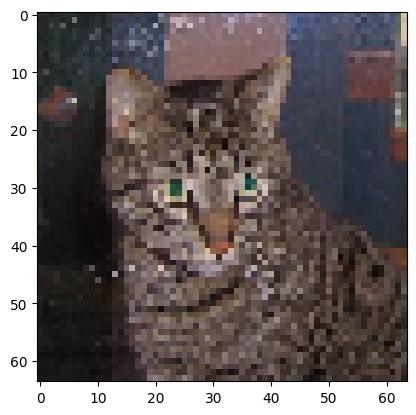

In [17]:
import matplotlib.pyplot as plt
plt.imshow(test_image[0]/255.0)
plt.show()